
=== Negative-value summary ===
No negative values detected.


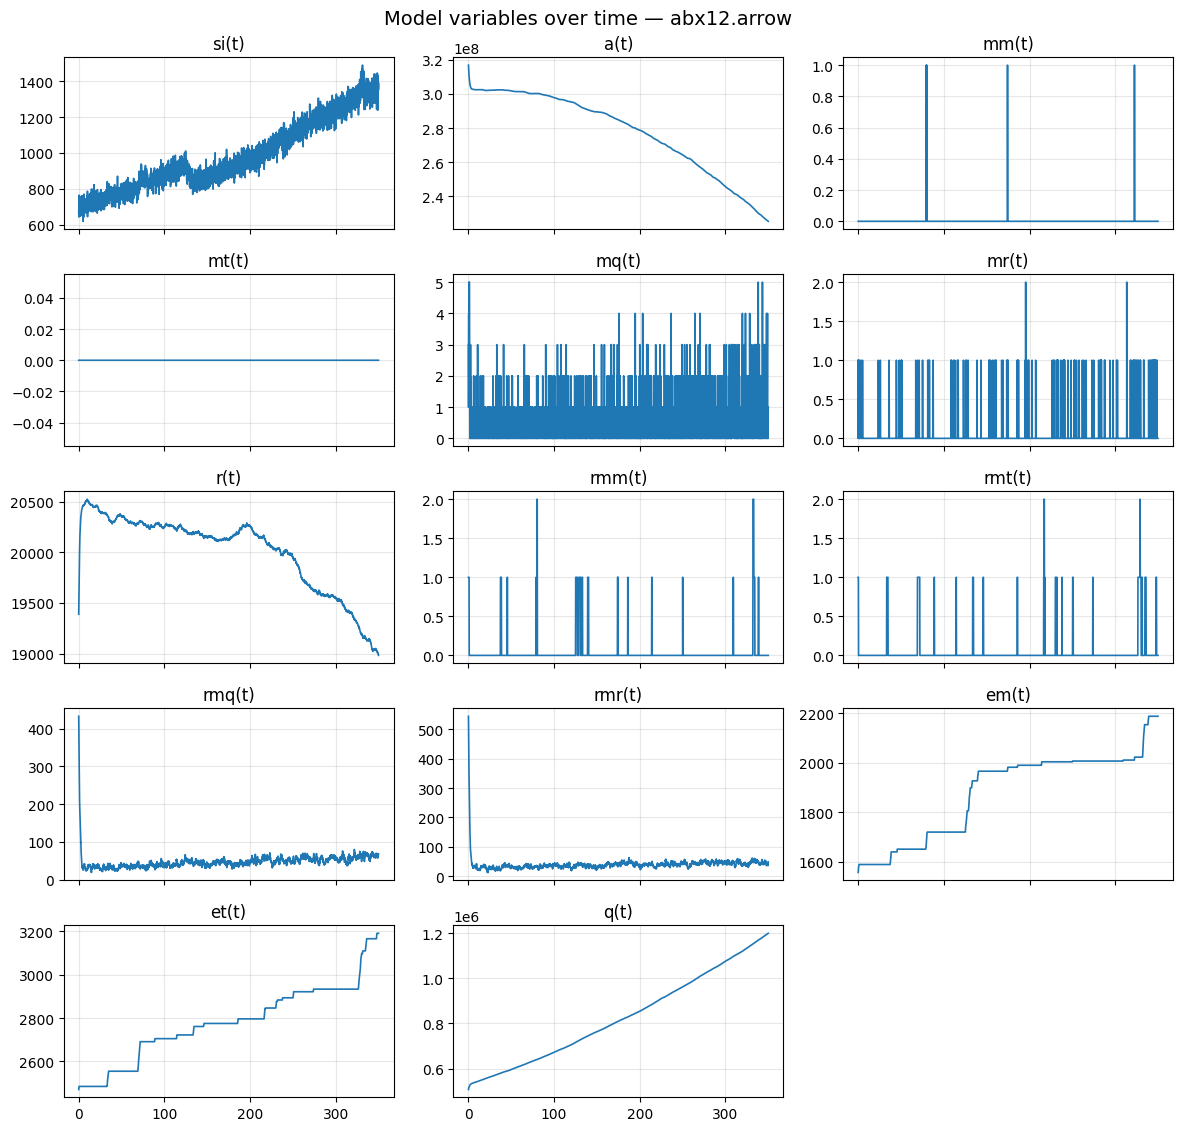

In [7]:
# === Plot all model variables over time & diagnose negatives ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# Choose file
# ------------------------------------------------------------
filename = "abx12.arrow"   # change as needed
df = read_arrow(filename)

time = df["timestamp"].values

# ------------------------------------------------------------
# Variables to inspect
# ------------------------------------------------------------
variables = [
    "si(t)", "a(t)",
    "mm(t)", "mt(t)", "mq(t)", "mr(t)",
    "r(t)", "rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)",
    "em(t)", "et(t)", "q(t)"
]

vars_present = [v for v in variables if v in df.columns]

# ------------------------------------------------------------
# Diagnose negatives
# ------------------------------------------------------------
negative_summary = []

for var in vars_present:
    values = df[var].values
    neg_mask = values < 0

    if np.any(neg_mask):
        negative_summary.append({
            "variable": var,
            "min_value": values.min(),
            "num_negative": np.sum(neg_mask),
            "first_time": time[neg_mask][0],
            "last_time": time[neg_mask][-1]
        })

neg_df = pd.DataFrame(negative_summary)

print("\n=== Negative-value summary ===")
if neg_df.empty:
    print("No negative values detected.")
else:
    print(neg_df.sort_values("min_value"))

# ------------------------------------------------------------
# Plot time series with negatives highlighted
# ------------------------------------------------------------
n = len(vars_present)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, nrows * 2.3),
    sharex=True
)
axes = axes.flatten()

for i, var in enumerate(vars_present):
    y = df[var].values
    axes[i].plot(time, y, lw=1.2, color="tab:blue")

    # Highlight negative values
    neg = y < 0
    if np.any(neg):
        axes[i].scatter(
            time[neg], y[neg],
            color="red", s=10, zorder=3,
            label="negative"
        )

    axes[i].set_title(var)
    axes[i].grid(alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[-1].set_xlabel("Time (min)")
fig.suptitle(f"Model variables over time — {filename}", fontsize=14)
plt.tight_layout()
plt.show()
